Dataset Shape: (252, 2)
Stock Volatility: 0.02248352775095041


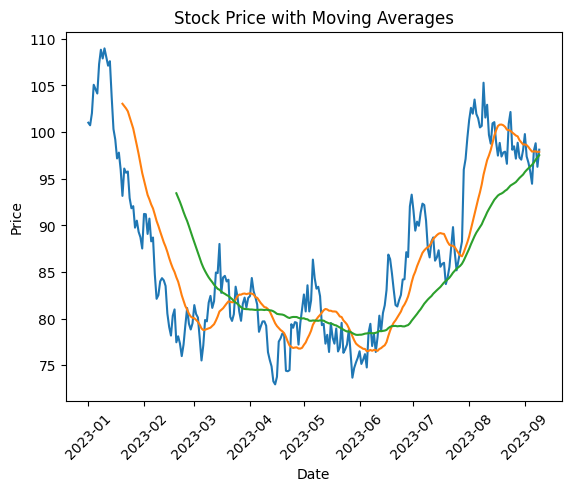

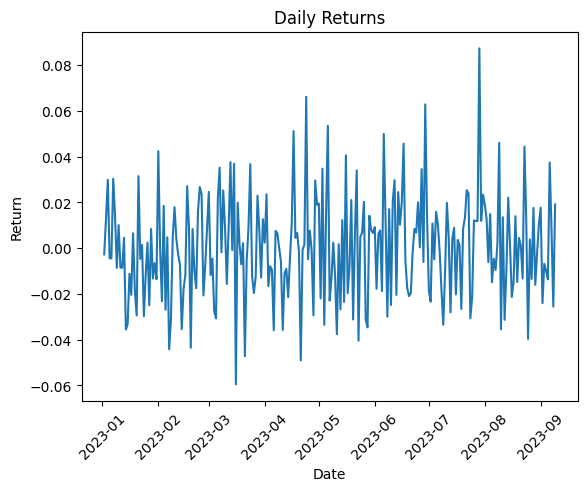

In [1]:
# ==================================
# STOCK MARKET ANALYSIS PROJECT
# ==================================

!pip install pandas numpy matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# -----------------------
# 1. Generate Stock Data
# -----------------------

days = 252  # trading days in a year
dates = pd.date_range(start="2023-01-01", periods=days)

price = 100 + np.cumsum(np.random.normal(0, 2, days))

df = pd.DataFrame({
    "Date": dates,
    "Close_Price": price
})

df.to_csv("stock_data.csv", index=False)

print("Dataset Shape:", df.shape)

# -----------------------
# 2. Moving Averages
# -----------------------

df["MA_20"] = df["Close_Price"].rolling(20).mean()
df["MA_50"] = df["Close_Price"].rolling(50).mean()

# -----------------------
# 3. Daily Returns
# -----------------------

df["Daily_Return"] = df["Close_Price"].pct_change()

# -----------------------
# 4. Volatility (Std Dev of Returns)
# -----------------------

volatility = df["Daily_Return"].std()
print("Stock Volatility:", volatility)

# -----------------------
# 5. Plot Price + Moving Averages
# -----------------------

plt.figure()
plt.plot(df["Date"], df["Close_Price"])
plt.plot(df["Date"], df["MA_20"])
plt.plot(df["Date"], df["MA_50"])
plt.title("Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()

# -----------------------
# 6. Plot Daily Returns
# -----------------------

plt.figure()
plt.plot(df["Date"], df["Daily_Return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.xticks(rotation=45)
plt.show()